# Star-shaped flat-top beam shaping at a finite distance

This notebook designs a **phase-only flat-optics element** that reshapes a Gaussian input beam into a star-shaped flat-top intensity distribution at a finite propagation distance. The phase is learned with a near-field PINN that solves the Monge--Ampère beam-shaping equation and is then validated with angular-spectrum propagation.

The workflow is:

1. define the Gaussian source and star target in the physical target plane,
2. train or load the near-field PINN phase profile,
3. visualize the learned phase mask, and
4. propagate the phase-modulated field to the target plane with wave optics.

## Imports and numerical backend

The notebook uses **PyTorch** for the PINN and automatic differentiation, the local `pinn_shaper` package for the near-field Monge--Amp\`ere solver, and standard plotting/interpolation utilities. If a CUDA GPU is available, PyTorch tensors are placed on the GPU by default.

In [1]:
# import the neccesary modules
import torch
if torch.cuda.is_available():
    torch.set_default_device('cuda')
    
import pinn_shaper
from pinn_shaper import Nearfield_PINN
from pinn_shaper import um, mm, cm
import matplotlib.pyplot as plt
import numpy as np
from pinn_shaper import load_image, create_interpolator
from scipy.ndimage import gaussian_filter as scipy_gaussian_filter


## Problem setup: Gaussian source and star target

The input beam is a Gaussian irradiance profile,

$$
I(x,y)=\exp\!\left[-2\left(\frac{\sqrt{x^2+y^2}}{w_I}\right)^2\right],
$$

sampled on a square source aperture of side `extent_source`. The desired output is a smoothed star-shaped flat-top image in a target plane of side `extent_target`, located a distance $z$ downstream.

For the finite-distance formulation, the normalized phase defines the ray map

$$
\bar t_x=\bar x+\frac{\bar\Phi_{\bar x}}{\bar K},
\qquad
\bar t_y=\bar y+\frac{\bar\Phi_{\bar y}}{\bar K},
$$

with

$$
\bar K=\sqrt{1-s^2(\bar\Phi_{\bar x}^2+\bar\Phi_{\bar y}^2)},
\qquad s=\frac{M}{z}.
$$

The PINN used here is a fully connected network with 4 hidden layers and 150 neurons per layer.

In [2]:
extent_source = 6*mm
extent_target = 6*mm

w_I = 1000*um  
def I_fun(x,y):
    # Source function. Gaussian beam with beam waist = w_I
    r = torch.sqrt(x**2+ y**2)
    return torch.exp(-(r/w_I)**2)**2

# Target function. Star-shaped Flat-Top beam
image = np.array(scipy_gaussian_filter(load_image('images/star.png'), 10, mode='nearest', cval=0), dtype = 'float32')
E_fun = create_interpolator(torch.tensor(image), mode='bilinear', region=[-extent_source/2,extent_source/2,-extent_source/2,extent_source/2], align_corners=True)


λ = 1.0*um # wavelength
z = 10*cm # distance between the source plane and the target plane 


# Initialize the PINN solver (the network is built now)
solver = Nearfield_PINN(I_fun, E_fun, extent_source, extent_target, z, λ,
                        integration_points=5000,
                        hidden_layers=4, num_features=150,
                        constrain=False,  symmetry=None)

## Inspect the normalized source and target

These plots check the two distributions used by the PDE residual: the Gaussian source irradiance at the phase mask and the prescribed star-shaped target irradiance in the output plane.

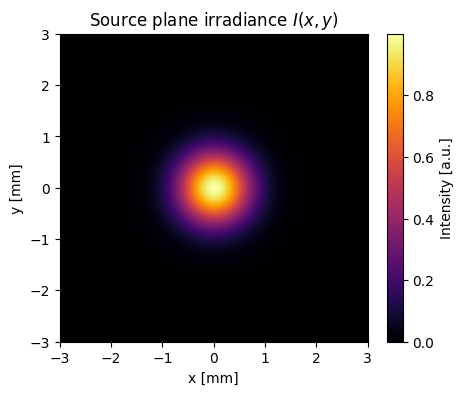

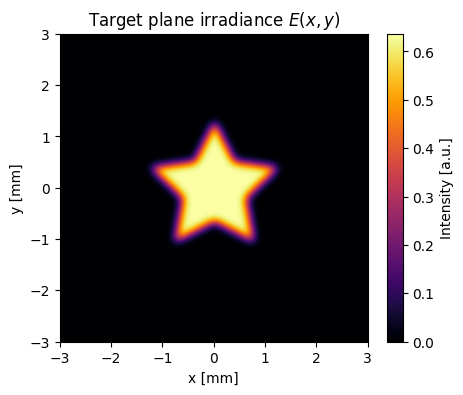

In [3]:
solver.plot_source_irradiance()
solver.plot_target_irradiance()

## PINN training schedule

The phase network is optimized in stages. Adam first gives a robust initial decrease of the residual, and L-BFGS then refines the phase using larger collocation sets. The loss combines the Monge--Amp\`ere residual with additional constraints weighted by `loss_weights`.

The notebook also reports test losses on separately sampled interior and boundary points to monitor whether the trained phase satisfies the PDE away from the training batch.

In [5]:
# Define common parameters for test loss and noise
residual_power = 1.5
loss_weights = [100.0, 1, 1]
noise_amplitude = 0.0
add_noise = False
effective_noise = noise_amplitude if add_noise else 0.0
num_test_interior = 1000
num_test_boundary = 200

# Now the user calls run_phase three times, each with a single optimizer.
# For example, first two phases using Adam and the final phase using LBFGS.

print("Run Phase 1: Adam")
solver.run_phase(
    optimizer_type='adam',
    iterations=1000,
    num_domain=1000,
    num_boundary=100,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=effective_noise,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    lr=0.001
)

print("Run Phase 2: Adam")
solver.run_phase(
    optimizer_type='adam',
    iterations=2000,
    num_domain=1500*10,
    num_boundary=100*10,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=effective_noise,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    lr=0.0001
)

print("Run Phase 3: LBFGS")
solver.run_phase(
    optimizer_type='lbfgs',
    num_domain=1500*15,
    num_boundary=100*15,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=0.001,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    max_iterations_lbfgs=2000,
    lr_lbfgs=1
)


print("Run Phase 4: LBFGS")
solver.run_phase(
    optimizer_type='lbfgs',
    num_domain=1500*15,
    num_boundary=100*15,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=0.0,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    max_iterations_lbfgs=2000,
    lr_lbfgs=1
)

# Print final test losses.
solver.print_final_test_loss(num_test_interior, num_test_boundary, residual_power, loss_weights, effective_noise)


Run Phase 1: Adam
Adam Iter     0: Loss = 0.09562831 (Interior = 0.00095628, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 1.54795289 (Interior = 0.01547953, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   100: Loss = 0.08977720 (Interior = 0.00089777, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.08972296 (Interior = 0.00089723, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   200: Loss = 0.08405799 (Interior = 0.00084058, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.08404735 (Interior = 0.00084047, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   300: Loss = 0.07870944 (Interior = 0.00078709, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.07402644 (Interior = 0.00074026, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   400: Loss = 0.07210091 (Interior = 0.00072101, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.06838132 (Interior = 0.00068381, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   500: 

Run Phase 4: LBFGS
LBFGS Iter   100: Loss = 0.00080753 Test Loss = 0.00049566 (Interior = 0.00000496, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter   200: Loss = 0.00078299 Test Loss = 0.00048975 (Interior = 0.00000490, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter   300: Loss = 0.00076078 Test Loss = 0.00047107 (Interior = 0.00000471, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter   400: Loss = 0.00073843 Test Loss = 0.00043341 (Interior = 0.00000433, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter   500: Loss = 0.00071664 Test Loss = 0.00041870 (Interior = 0.00000419, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter   600: Loss = 0.00069697 Test Loss = 0.00040899 (Interior = 0.00000409, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter   700: Loss = 0.00067933 Test Loss = 0.00041831 (Interior = 0.00000418, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter   800: Loss = 0.00066069 Test Loss = 0.00040850 (Interior = 0.00000409, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter   

## Load the trained model

Training can take time, so this cell loads a previously saved checkpoint. Uncommenting the `torch.save(...)` line after training would save a new set of model weights.

In [5]:
#torch.save(solver.net.state_dict(), 'star_flat-top_model.pth') # save the trained model
solver.net.load_state_dict(torch.load('saved_models/star_flat-top-nearfield_model.pth')) # load the trained model

<All keys matched successfully>

## Visualize the learned phase mask

The learned phase $\Phi(x,y)$ is evaluated on a dense grid. The contour plot shows the smooth phase potential, while the wrapped phase modulo $2\pi$ shows the phase pattern that would be implemented by a phase-only optical element.

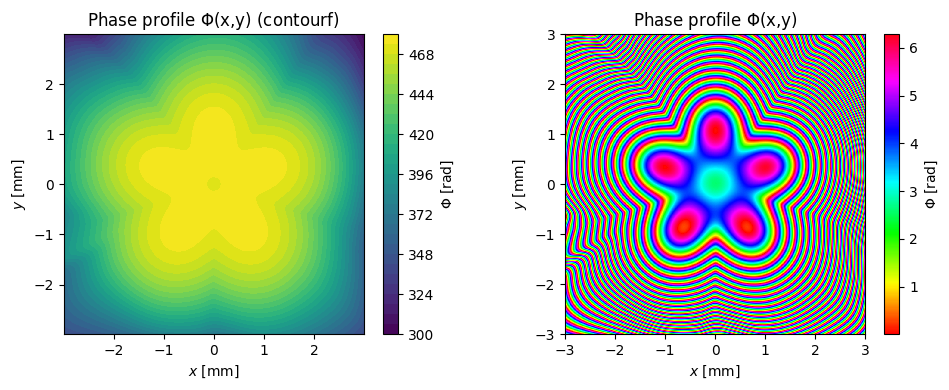

In [8]:
phi_spline = solver.get_phi_spline()


nx, ny = 1000, 1000
x = np.linspace(-solver.M, solver.M, nx)
y = np.linspace(-solver.M, solver.M, ny)
X, Y = np.meshgrid(x, y, indexing='xy')




fig, axs = plt.subplots(1, 2, figsize=(10, 4))
ax1 = axs[0]
im = ax1.contourf(phi_spline(x,y), origin = 'lower',  levels = 30, extent = [x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = r'$\Phi$ [rad]')
ax1.set_ylabel("$y$ [mm]")
ax1.set_xlabel('$x$ [mm]')
ax1.set_title(r"Phase profile $\Phi$(x,y) (contourf)")
ax1.set_aspect(1) 

ax2 = axs[1]
im = ax2.imshow((phi_spline(x,y) )  %(np.pi*2), origin = 'lower', cmap = 'hsv', interpolation = 'none', extent = [x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = r'$\Phi$ [rad]')
ax2.set_ylabel("$y$ [mm]")
ax2.set_xlabel('$x$ [mm]')
ax2.set_title(r"Phase profile $\Phi$(x,y)")
ax2.set_aspect(1) 

fig.tight_layout()
plt.show()


## Angular-spectrum validation at the target plane

The PINN is trained using a geometrical ray-mapping PDE, so the final phase is validated independently with scalar wave propagation. The input field after the mask is

$$
U(x,y)=\sqrt{I(x,y)}\,e^{i\Phi(x,y)},
$$

and it is propagated by the angular-spectrum method (ASM) over the distance $z$ to the target plane. Agreement between the propagated intensity and the target confirms that the ray-derived phase is also useful in a wave-optics simulation.

### Install/import the propagation package

The following cells use `diffractsim` to perform angular-spectrum propagation. If the package is already installed in your environment, the installation line can be skipped.

In [ ]:
!pip install diffractsim

### Build and propagate the complex field

This cell constructs the phase-modulated field on a high-resolution grid and propagates it by the distance $z$. The propagated field `F.E` is then used to compute the target-plane intensity $|U_z(x,y)|^2$.

In [9]:
import diffractsim
diffractsim.set_backend("CPU")
from diffractsim import MonochromaticField

def I_fun(x,y):
    r = np.sqrt(x**2+ y**2)
    return np.exp(-(r/w_I)**2)**2

F = MonochromaticField(wavelength=1*um, extent_x = extent_source, extent_y = extent_source, Nx=2048, Ny=2048)
F.E = np.sqrt(I_fun(F.xx,F.yy)) * np.exp(1j*(phi_spline(F.x,F.y)))
F.propagate(z)


### Compare the propagated intensity with the target

The left panel shows the simulated intensity in the target plane. The right panel compares the central cross section at $y=0$ with the target profile, which makes the flat-top plateau and the edge transitions easier to inspect.

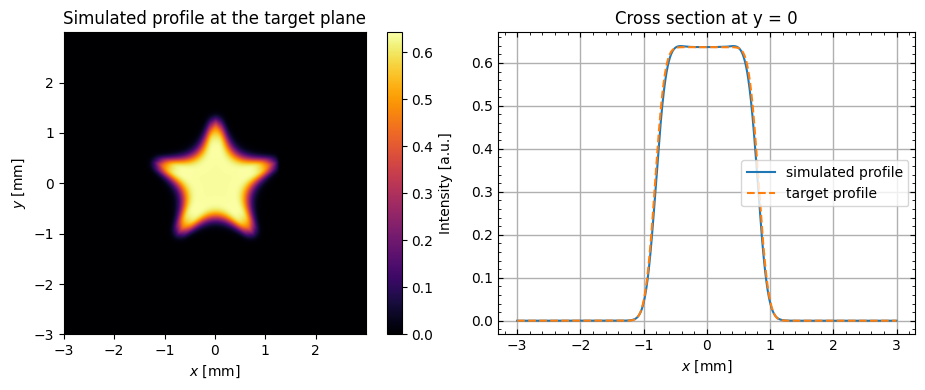

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
ax1 = axs[0]
im = ax1.imshow(np.abs(F.E)**2, origin = 'lower', cmap ='inferno', extent = [F.x[0]/mm, F.x[-1]/mm, F.y[0]/mm,  F.y[-1]/mm ], aspect = 'auto')
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = 'Intensity [a.u.]')
ax1.set_ylabel("$y$ [mm]")
ax1.set_xlabel('$x$ [mm]')
ax1.set_title(r"Simulated profile at the target plane")
ax1.set_aspect(1) 


ax2 = axs[1]
ax2.tick_params(axis='both', which="both", direction="in",right=True, top=True,)
ax2.minorticks_on()
ax2.grid(which='major', linestyle='-', linewidth=1.0)
ax2.plot(F.x/mm, np.abs(F.E)[F.Ny//2, :]**2 , label = 'simulated profile' )

x_torch = torch.from_numpy(np.array(F.x,dtype='float32')).to('cuda')
ax2.plot(F.x/mm, solver.E_fun_norm(x_torch,x_torch*0).cpu().numpy().ravel(), '--', label = 'target profile' ) 
ax2.tick_params(axis='both', which ="both", direction="in",right=True, top=True)
ax2.minorticks_on()
ax2.set_title('Cross section at y = 0')
#ax2.set_ylabel("Intensity [a.u.]")
ax2.set_xlabel('$x$ [mm]')

ax2.legend()

fig.tight_layout()

plt.show()
